<font size="5" color="red"><b>ch4. 머신러닝 모형 최적화</b></font>

# 1절. 변수 선택과 차원 축소## 1-1 변수선택과 차원축소
- 종속변수에 영향을 주는 변수들을 찾아 학습에 사용할 독립변수의 수를 줄임 (어떻게 하면 score를 높일 수 있을지?)
- 과적합과 변수들 사이의 다중공선성(변수들간 강한 상관관계)을 줄일 수 있음
 * 회귀계수 해석이 어려워짐. 모델 예측력이 좋아도 해석력이 떨어짐(어떤 변수가 제일 큰 요인인지 잘), p값이나 유의성 검정이 왜곡될 수 있음
- 모형의 학습 시간을 줄일 수 있음
- 주성분분석, 상관분석, **분류모형의 feature_importance_, 예측 모형의 coef_**
- SelectKBest : 가장 높은 score에 따라 K개의 특징을 선택

## 1-2 주성분분석(PCA, Principal Component Anaysis)
- 주성분분석은 변수 선택 및 차원축소 방법(기존의 모든 변수를 조합하여 새로운 변수로 만듦) 으로 널리 사용
- 주성분 분석은 상관관계가 있는 변수들을 선형결합해서 **분산이 극대화된 상관관계가 없는 새로운 변수(주성분)들로 축약**하는 것
- 주성분 분석은 사실 선형대수학이라기보다는 선형대수학의 활용적인 측면이 강하며 영상인식, 통계 데이터분석(주성분 찾기), 데이터 압축, 노이즈제거 등 여러 분야에 사용
- 영상처리에서 많이 활용 : 여러개의 영상 중 대표 이미지를 찾을 때 활용

In [3]:
import seaborn as sns
from sklearn.decomposition import PCA
iris = sns.load_dataset('iris')
iris_X, iris_y = iris.iloc[:, :-1], iris.species
iris_X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
pca = PCA(n_components=2) #n_components=2:주성분의 갯수
pca.fit(iris_X)
iris_pca = pca.transform(iris_X)
iris_pca[:5]

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451]])

In [8]:
# 각 주성분의 계수 : 각 주성분이 원래 특성들과 어떤 관계가 있는지 나타내는 가중치
pca.components_ #주성분 벡터
# 주성분1 = 0.36138659*x1 -0.08452251*x2 + 0.85667061*x3 + 0.3582892 *x4
# 주성분2 = -0.65658877*x1 + 0.73016143*x2 + 0.1733736*x3 + 0.07548102*x4

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

In [9]:
# 설명분산 : 각 주성분이 원래 특성의 분산을 얼마나 설명하는지 나타내는 값
pca.explained_variance_

array([4.22824171, 0.24267075])

In [11]:
# 설명분산율 : 각 주성분이 전체 분산에서 차지하는 비율(0~1 사이의 값) : 주성분 결과 특성은 97.76852%
pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

## 1-3 상관관계 확인
- 각 변수들끼리의 상관관계 확인(시각화), 종속변수와 상관관계가 높은 변수들만 선택


In [14]:
import pandas as pd
redwine = pd.read_csv('data/winequality-red.csv' , sep=';')
redwine.sample()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
443,10.0,0.44,0.49,2.7,0.077,11.0,19.0,0.9963,3.23,0.63,11.6,7


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# cmap의 종류 : https://jrc-park.tistory.com/155 
# http://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap 
# http://seaborn.pydata.org/examples/many_pairwise_correlations.html 

<Axes: >

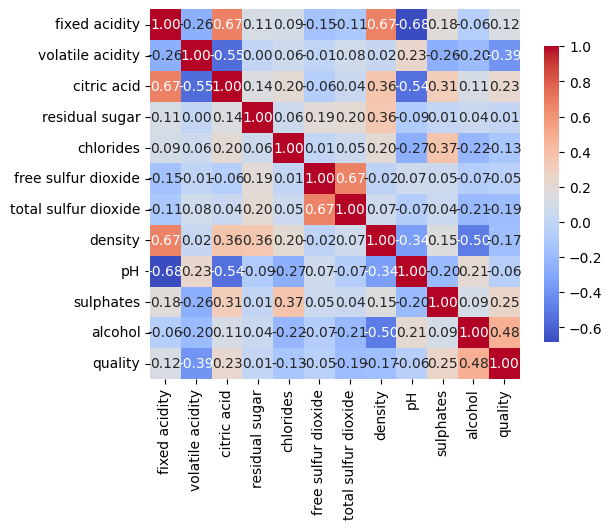

In [16]:
corr = redwine.corr()
# 상관관계 결과를 히트맵으로 시각화
# http://seaborn.pydata.org/examples/many_pairwise_correlations.html
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={"shrink": .8})


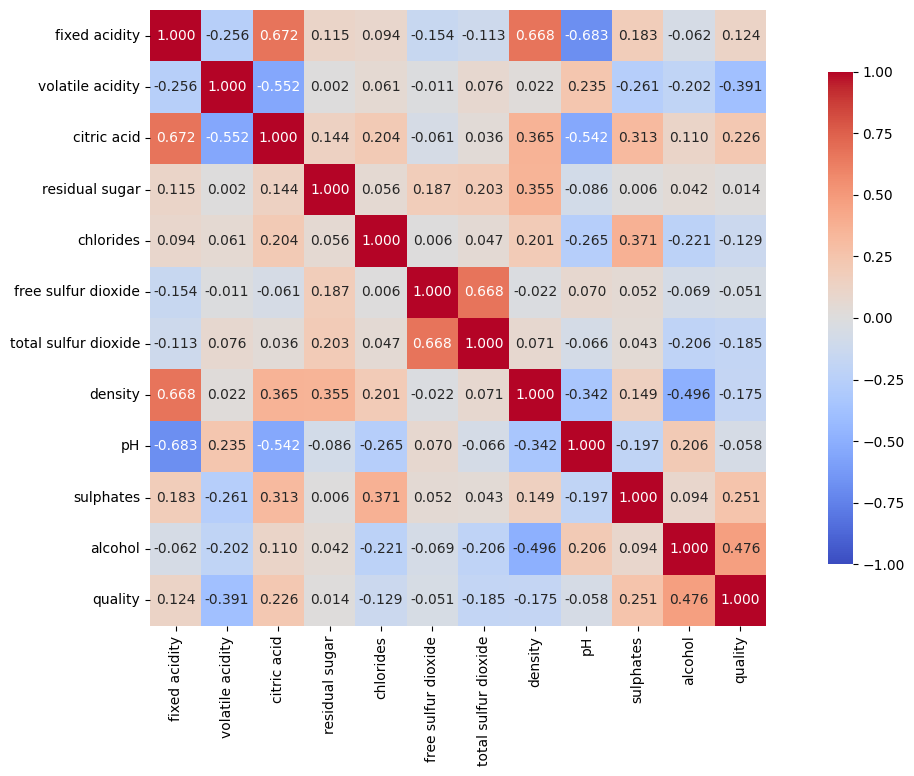

In [20]:
plt.figure(figsize=(16, 8))
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.show()

In [21]:
np.triu(np.ones_like(corr), k=0) # 대각선 포함 위가 1인 삼각행렬
np.triu(np.ones_like(corr), k=1) # 대각선 제외 위가 1인 삼각행렬
np.tril(np.ones_like(corr), k=0) # 대각선 포함 아래가 1인 삼각행렬
np.tril(np.ones_like(corr), k=-1) # 대각선 제외 아래가 1인 삼각행렬

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.]])

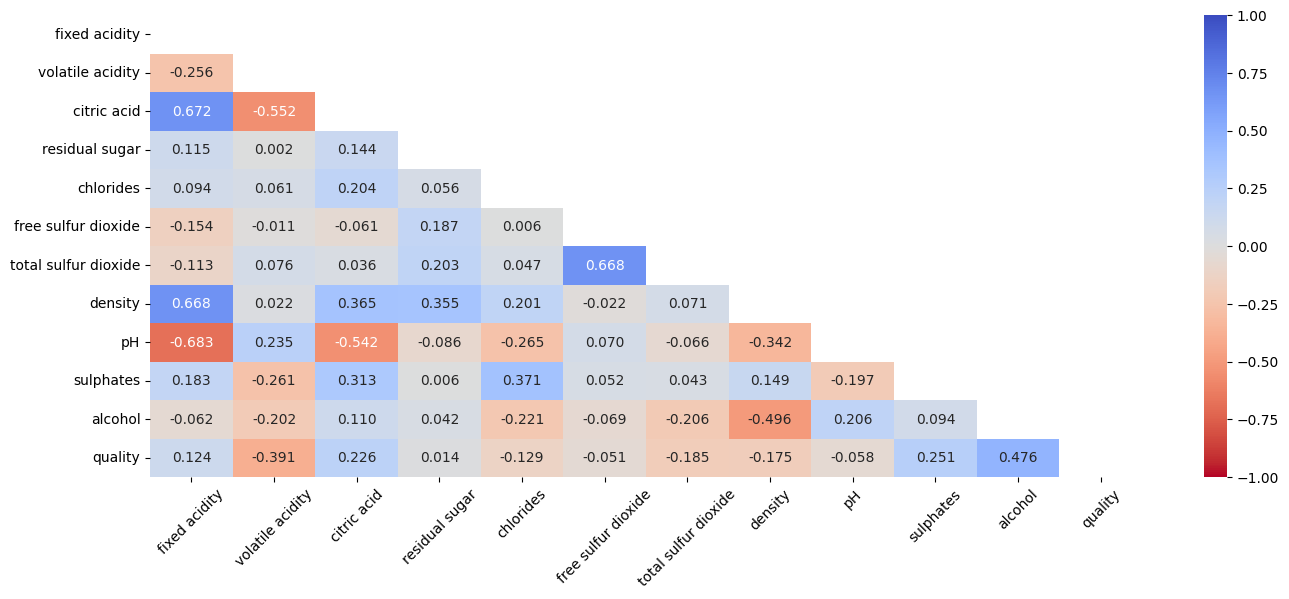

In [23]:
plt.figure(figsize=(16,6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm_r', mask=mask)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

## 1-4 분류모형의 Feature importance
- 분류모형의 feature_importance_  속성은 각 독립변수들이 종속변수에 영향을 주는 정도
- LogisticRegression이나 SVC, MLP, GaussianNB등은 feature_importance_가 없음
- 그 외 분류모형은 사용가능

In [25]:
from sklearn.model_selection import train_test_split
X = redwine.iloc[:, :-1]  # 마지막 열을 제외한 모든 열
y = redwine.iloc[:, -1]   # 마지막 열만 선택
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3)
train_X.shape, test_X.shape, train_y.shape, test_y.shape

((1119, 11), (480, 11), (1119,), (480,))

In [29]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10, #트리 갯수 10개
                                  random_state=10, #랜덤시드 고정
                                  )
rf_model.fit(train_X, train_y)

RandomForestClassifier(n_estimators=10, random_state=10)

In [30]:
rf_model.feature_importances_ # 특성 중요도

array([0.06753115, 0.10378444, 0.07528428, 0.08206159, 0.08367241,
       0.06322938, 0.11628978, 0.08277911, 0.06557295, 0.10822624,
       0.15156867])

In [31]:
train_X.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

In [36]:
features = pd.DataFrame(data =  np.c_[X.columns, rf_model.feature_importances_], # 특성 중요도와 특성 이름을 합쳐서 출력
                        columns=['feature', 'importance'])
features['importance'].sum() 

1.0

In [41]:
features.sort_values(by='importance', ascending=False, inplace=True)
features.reset_index(drop=True, inplace=True)
features

,feature,importance
0,alcohol,0.151569
1,total sulfur dioxide,0.11629
2,sulphates,0.108226
3,volatile acidity,0.103784
4,chlorides,0.083672
5,density,0.082779
6,residual sugar,0.082062
7,citric acid,0.075284
8,fixed acidity,0.067531
9,pH,0.065573


### feature_importance_를 이용한 변수 중요도 시각화